# Accessibility of Basketball Courts in Durham County for Student Aged Populations

In [ ]:
#%pip install osmnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

DATA = Path("geog592-ompatel/homework/week07/data")
DATA.mkdir(parents=True, exist_ok=True)

CRS = "EPSG:2264" # NAD83 / North Carolina State Plane (US feet to measure buffers)
PLACE = "Durham County, North Carolina, USA"
REGION = [PLACE,
          "Orange County, North Carolina, USA",
          "Wake County, North Carolina, USA"]
HALF_MILE, ONE_MILE = 2640, 5280

## Downloading Data

In [9]:
# county boundary
county = ox.geocode_to_gdf(PLACE)[["geometry"]].assign(name="Durham County").to_crs(CRS)
county.to_file(DATA / "durham_county.gpkg")

# basketball courts across 3 counties
pitches = ox.features_from_place(REGION, tags={"leisure": "pitch"})
courts = pitches[pitches["sport"].fillna("").str.contains("basketball")].copy()
if "access" in courts.columns:
    courts = courts[courts["access"].isin(["private", "customers", "no"])]
courts = courts.to_crs(CRS)
courts["geometry"] = courts.geometry.centroid
courts = courts[["sport", "geometry"]].reset_index(drop=True)

# polygons of parks in Durham County
parks = ox.features_from_place(PLACE, tags={"leisure": "park"})
parks = parks[parks.geom_type.isin(["Polygon", "MultiPolygon"])].to_crs(CRS)
parks = parks.reindex(columns=["name", "geometry"]).reset_index(drop=True)
parks.to_file(DATA / "osm_parks_durham.gpkg")


## Loading  Data

In [ ]:
county  = gpd.read_file(DATA / "durham_county.gpkg")
courts  = gpd.read_file(DATA / "osm_courts_region.gpkg")
parks   = gpd.read_file(DATA / "osm_parks_durham.gpkg")

shp = next((DATA / "edge_schools").rglob("*.shp"))
schools = gpd.read_file(shp)
schools = schools[schools["CNTY"] == "37063"].to_crs(CRS) 
schools = schools[["NCESSCH", "NAME", "geometry"]]

print(len(courts), "regional courts |", len(parks), "parks |", len(schools), "Durham schools")

## Clipping Data: Layer 1

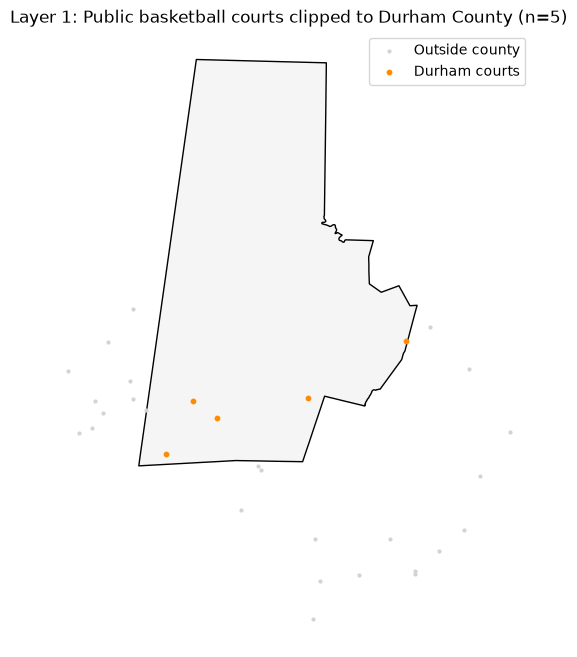

In [10]:
# which public courts are inside of Durham County?

courts_durham = gpd.clip(courts, county)
courts_durham.to_file(DATA / "layer1_courts_durham.gpkg")

ax = county.plot(color="whitesmoke", edgecolor="black", figsize=(8, 8))
courts.plot(ax=ax, color="lightgray", markersize=4, label="Outside county")
courts_durham.plot(ax=ax, color="darkorange", markersize=10, label="Durham courts")
ax.set_title(f"Layer 1: Public basketball courts clipped to Durham County (n={len(courts_durham)})")
ax.legend(); ax.set_axis_off()

## Buffering: Layer 2

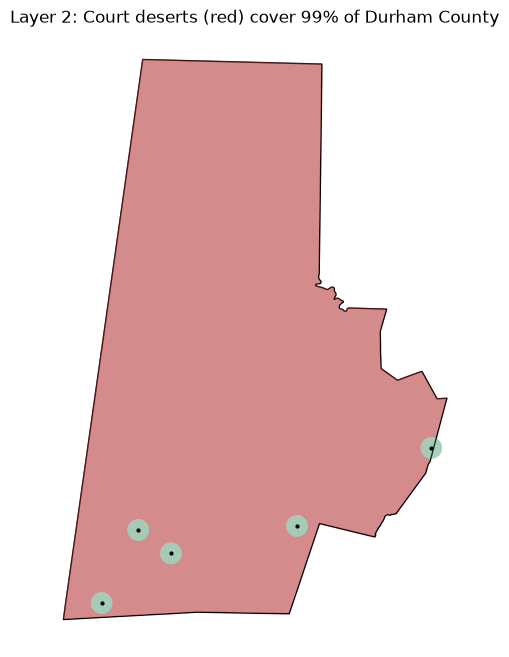

In [11]:
# which parts of the county are more than 1/2 mile walking distance from any court?

walkshed = courts_durham.buffer(HALF_MILE)
walkshed = gpd.GeoDataFrame(geometry=[walkshed.union_all()], crs=CRS)  

deserts = gpd.overlay(county, walkshed, how="difference")
deserts.to_file(DATA / "layer2_court_deserts.gpkg")

pct = deserts.area.sum() / county.area.sum() * 100
ax = county.plot(color="whitesmoke", edgecolor="black", figsize=(8, 8))
deserts.plot(ax=ax, color="firebrick", alpha=0.5)
walkshed.plot(ax=ax, color="seagreen", alpha=0.4)
courts_durham.plot(ax=ax, color="black", markersize=4)
ax.set_title(f"Layer 2: Court deserts (red) cover {pct:.0f}% of Durham County")
ax.set_axis_off()

## Intersection: Layer 3

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/tools/overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 5 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


,name,acres
2,Eno River State Park,759.077596
11,West Point on the Eno,404.351088
63,Little River Park,250.719600
95,Patterson Road Waterfowl Impoundment,104.695704
58,Sandy Creek Park,101.555901
68,Leigh Farm,95.529024
66,Penny's Bend Nature Preserve,81.944283
1,River Forest Park,73.650022
30,Twin Lakes Park,73.582937
96,Bluff Waterfowl Impoundment,62.576522


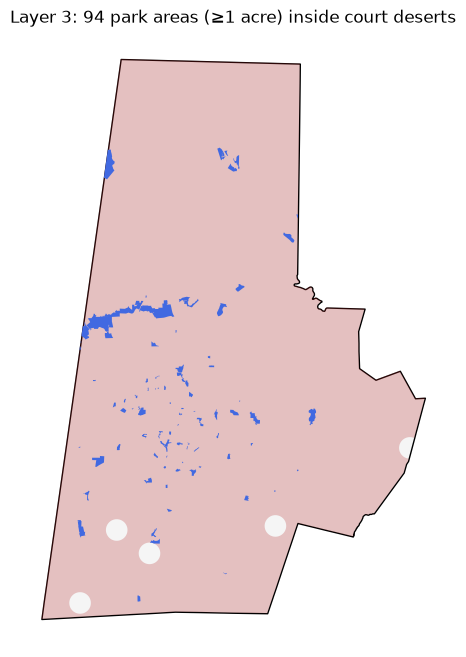

In [14]:
# where is there existing parkland inside of noticeable court deserts that may serve as a potential site for a new basketball court?

candidate_sites = gpd.overlay(parks, deserts.drop(columns="name"), how="intersection")
candidate_sites["acres"] = candidate_sites.area / 43560
candidate_sites = candidate_sites[candidate_sites["acres"] >= 1] 
candidate_sites.to_file(DATA / "layer3_candidate_park_sites.gpkg")

ax = county.plot(color="whitesmoke", edgecolor="black", figsize=(8, 8))
deserts.plot(ax=ax, color="firebrick", alpha=0.25)
candidate_sites.plot(ax=ax, color="royalblue")
ax.set_title(f"Layer 3: {len(candidate_sites)} park areas (≥1 acre) inside court deserts")
ax.set_axis_off()

candidate_sites.sort_values("acres", ascending=False)[["name", "acres"]].head(10)

## Attribute Join